## Import the CIFAR-10


In [10]:
# libs needed
import tarfile
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
print("ok")

ok


## Load the data


In [11]:
with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall()

# from https://www.cs.toronto.edu/~kriz/cifar.html
# Using the unpickle function, each of the bach files contains a dictionary with the following contents:
#   data --> a 10000x3072 numpy array of uint8's.
#       - Each row of the array stores a 32x32 colour image.
#       - Where the first 1024 entries contain the red channel, then 1024 for green, and then 1024 for blue
#       - The image is stored in row-major order, so the first 32 entries of the array are red channel values of the first row of the image
# SÅ data[i] indeholder 3 arrays af 1024 hver --> [ R (1024 values), G (1024 values), B (1024 values) ]
#

#   labels --> a list of 10000 numbers in the range 0-9
#       - The number at index i indicates the label of the i'th image in the array data

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

/tmp/ipykernel_19627/3756646088.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


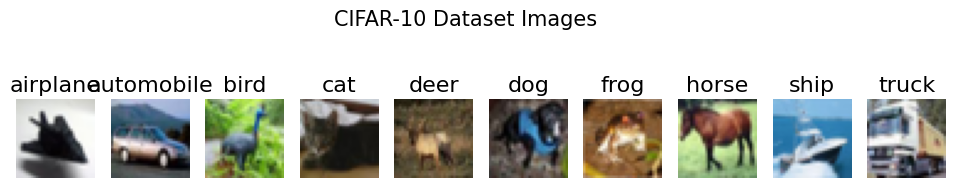

In [12]:
x_train = [] # the data
y_train = [] # the labels

for i in range(1,6):
  dict_train = unpickle(f'cifar-10-batches-py/data_batch_{i}')
  x_train.append(dict_train[b'data'])
  y_train.append(dict_train[b'labels'])

# Make them a long list instead of a list of lists
x_train = np.concatenate(x_train)
y_train = np.concatenate(y_train)

# The test data
dict_test = unpickle(f'cifar-10-batches-py/test_batch')
x_test = dict_test[b'data']
y_test = dict_test[b'labels']

# reshape so we get 50000,3,32,32 --> https://github.com/n-kostadinov/cnn-image-classification-cifar-10-from-scratch/blob/master/cnn-image-classification-cifar-10-from-scratch.ipynb

#features = batch['data'].reshape((len(batch['data']), 3, 32, 32)).transpose(0, 2, 3, 1)
x_train = x_train.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0   # (N, C, H, W)
# x_train = x_train.transpose(0, 2, 3, 1)    # (N, H, W, C)

x_test  = x_test.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
# x_test = x_test.transpose(0, 2, 3, 1)


# total size
n_train = x_train.shape[0]
n_test = x_test.shape[0]
n_total = n_train + n_test





# ------------------------------------------------------------
# pick one example of each digit
# ------------------------------------------------------------
examples = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    img = np.transpose(x_train[idx], (1, 2, 0))   # CHW -> HWC only for plotting
    examples.append(img)


# ------------------------------------------------------------
# create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

gs = fig.add_gridspec(2, 10, height_ratios=[1,1.2])

# title
fig.suptitle("CIFAR-10 Dataset Images", fontsize=15)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# ------------------------------------------------------------
# row of example digits
# ------------------------------------------------------------
for i in range(10):
    ax = fig.add_subplot(gs[0,i])

    ax.imshow(examples[i])
    # ax.set_title(str(i), fontsize=16)
    ax.set_title(str(classes[i]), fontsize=16)
    ax.axis("off")


## Convert to torch tensors

In [13]:
X = torch.tensor(x_train, dtype=torch.float32)
Y = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(x_test, dtype=torch.float32)
Y_test = torch.tensor(y_test, dtype=torch.long)

# Setting up the CNN


In [14]:
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, num_filters=32, hidden_size=64, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=num_filters, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(num_filters, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x=self.conv1(x)
        x=self.relu(x)
        x=torch.mean(x,dim=(2,3))

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        # x = F.softmax(x, dim=1) # Apply softmax across the class dimension
        return x

# Training the model

In [15]:
import torch.optim as optim

# Instantiate the model
model = SmallCNN()
print(model)


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Number of steps for training
num_steps = 2000
batch_size=32


# Training loop
for step in range(num_steps):

    idx = torch.randperm(X.size(0))[:batch_size]
    X_batch = X[idx]
    Y_batch = Y[idx]
    
    # Forward pass
    outputs = model(X_batch)
    loss = criterion(outputs, Y_batch)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (step+1) % 100 == 0:
      print(f'Epoch [{step+1}/{num_steps}], Loss: {loss.item():.4f}')

print('Training finished.')

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [100/2000], Loss: 2.2835
Epoch [200/2000], Loss: 2.0693
Epoch [300/2000], Loss: 2.1231
Epoch [400/2000], Loss: 2.0910
Epoch [500/2000], Loss: 2.1385
Epoch [600/2000], Loss: 2.3687
Epoch [700/2000], Loss: 2.0153
Epoch [800/2000], Loss: 1.9987
Epoch [900/2000], Loss: 2.1266
Epoch [1000/2000], Loss: 2.0736
Epoch [1100/2000], Loss: 2.2143
Epoch [1200/2000], Loss: 2.2153
Epoch [1300/2000], Loss: 2.1048
Epoch [1400/2000], Loss: 1.8061
Epoch [1500/2000], Loss: 1.9804
Epoch [1600/2000], Loss: 2.1189
Epoch [1700/2000], Loss: 2.0031
Epoch [1800/2000], Loss: 1.8311
Epoch [1900/2000], Loss: 1.9841
Epoch [2000/2000], Loss: 2.0337
Training finished.


# Evaluate the model

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

model.eval()

def get_predictions(model, X, Y, batch_size=256):
    all_preds = []
    all_true = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            X_batch = X[i:i+batch_size]
            Y_batch = Y[i:i+batch_size]

            outputs = model(X_batch)              # logits
            preds = torch.argmax(outputs, dim=1)  # predicted class index

            all_preds.append(preds.cpu())
            all_true.append(Y_batch.cpu())

    y_pred = torch.cat(all_preds)
    y_true = torch.cat(all_true)
    return y_true, y_pred


# Get predictions
y_true_train, y_pred_train = get_predictions(model, X, Y)
y_true_test, y_pred_test = get_predictions(model, X_test, Y_test)

# Accuracy
train_acc = (y_pred_train == y_true_train).float().mean().item() * 100
test_acc = (y_pred_test == y_true_test).float().mean().item() * 100

print(f"Accuracy on training data: {train_acc:.2f}%")
print(f"Accuracy on test data: {test_acc:.2f}%")

# Class names
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Classification report
print("\nClassification report on test data:")
print(classification_report(y_true_test.numpy(), y_pred_test.numpy(), target_names=classes))

Accuracy on training data: 24.33%
Accuracy on test data: 25.18%

Classification report on test data:
              precision    recall  f1-score   support

    airplane       0.34      0.59      0.43      1000
  automobile       0.44      0.01      0.03      1000
        bird       0.15      0.32      0.21      1000
         cat       0.12      0.00      0.00      1000
        deer       0.30      0.41      0.34      1000
         dog       0.16      0.19      0.17      1000
        frog       0.26      0.31      0.29      1000
       horse       0.29      0.05      0.08      1000
        ship       0.30      0.24      0.27      1000
       truck       0.28      0.40      0.33      1000

    accuracy                           0.25     10000
   macro avg       0.26      0.25      0.21     10000
weighted avg       0.26      0.25      0.21     10000



## Visualize the confusion matrix


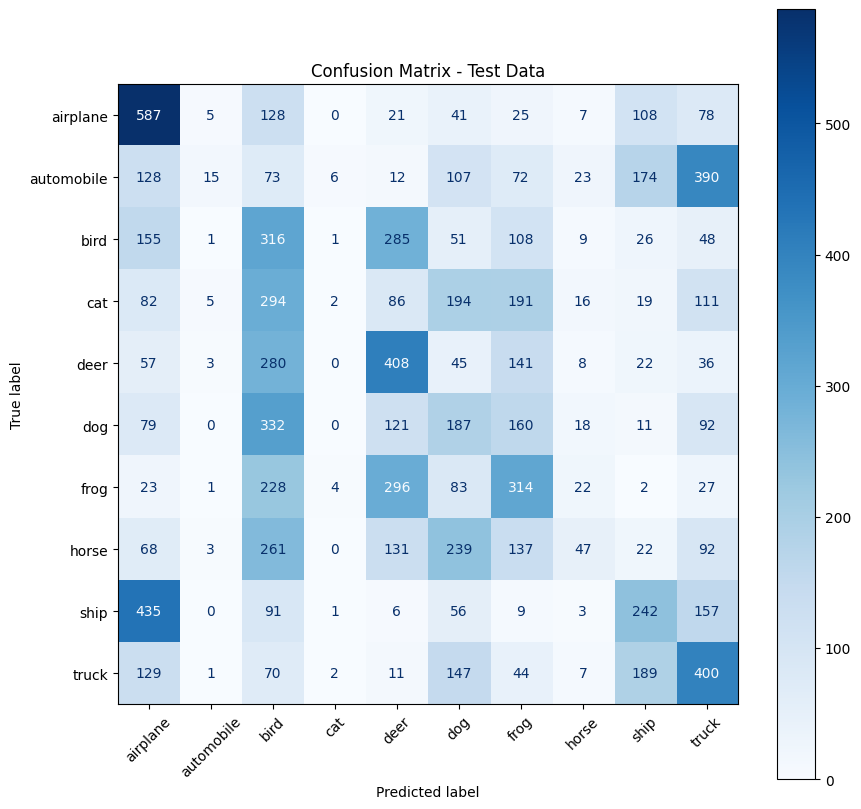

In [17]:
# Confusion matrix
cm = confusion_matrix(y_true_test.numpy(), y_pred_test.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - Test Data")
plt.show()

## Visualize the 20 learned convolutional features

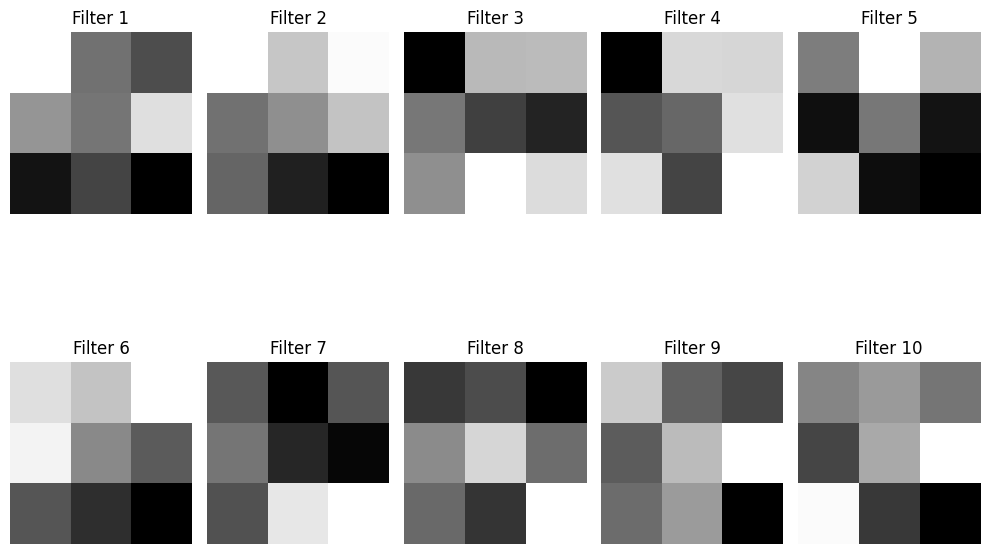

In [18]:
filters = model.conv1.weight.detach().cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()